The notebook executes two main experiments:

### 1. Metric Optimization & Regularization Path
* Fits the `LogisticLassoFISTA` model across a grid of 50 regularization strengths ($\lambda$).
* Tracks and evaluates the model's performance on a validation set using multiple metrics: **Balanced Accuracy, F1 Score, ROC AUC, Precision, and Recall**.
* Generates plots to visualize the validation score paths for each metric.
* Plots the Lasso coefficient shrinkage path, dynamically highlighting the "best" $\lambda$ chosen by each metric.

### 2. Equivalence Check (FISTA vs. Sklearn)
* Fits both the custom FISTA model and Sklearn's `LogisticRegression` (using the `liblinear` solver) on a chosen equivalent penalty ($\lambda = 0.01$ ()defaults mapped to Sklearn's $C$).
* Performs a direct mathematical check by outputting the maximum absolute difference between the feature coefficients and intercepts learned by both models.
* Compares the final prediction match rate and test-set performance (Balanced Accuracy, F1, ROC AUC).

#### helper functions

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.models.logistic_lasso_fista import LogisticLassoFISTA

def load_and_prep_data(filepath="../data/gallstones.csv"):
    """Loads dataset and splits into Train/Valid/Test."""
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found. Generating synthetic data for the experiment.")
        from sklearn.datasets import make_classification
        X, y = make_classification(n_samples=500, n_features=20, n_informative=5, random_state=42)
    else:
        df = pd.read_csv(filepath)
        X = df.drop(columns=['class']).values
        y = df['class'].values

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_valid_std = scaler.transform(X_valid)
    X_test_std = scaler.transform(X_test)
    
    return X_train_std, X_valid_std, X_test_std, y_train, y_valid, y_test

def run_metric_experiments(X_train, y_train, X_valid, y_valid):
    """Visualizes FISTA behavior when optimizing different metrics."""
    metrics_to_test = ["balanced_accuracy", "f1", "roc_auc", "precision", "recall"]
    
    print("="*60)
    print(" PART 1: FISTA METRIC OPTIMIZATION")
    print("="*60)

    fig_val, ax_val = plt.subplots(figsize=(8, 6))
    ax_val.set_title("Validation Paths Comparison")
    ax_val.set_xlabel("Lambda")
    ax_val.set_ylabel("Metric Score")
    ax_val.set_xscale("log")
    ax_val.grid(True, which="both", linestyle=":", linewidth=0.5)

    best_lambdas = {}
    last_fista_model = None

    for metric in metrics_to_test:
        print(f"\nEvaluating metric: {metric.upper()}")
        
        fista_model = LogisticLassoFISTA(standardize=False, max_iter=2000)

        fista_model.fit(
            X_train, y_train, 
            X_valid=X_valid, y_valid=y_valid, 
            metric=metric, 
            n_lambdas=50
        )
        
        print(f"  -> Best Lambda: {fista_model.best_lambda_:.6f}")
        print(f"  -> Best Validation {metric}: {fista_model.best_score_:.4f}")
        
        ax_val.plot(
            fista_model.lambdas_, 
            fista_model.validation_scores_, 
            marker='o', 
            markersize=4,
            label=metric
        )
        
        best_lambdas[metric] = fista_model.best_lambda_
        last_fista_model = fista_model

    ax_val.legend(loc='best')
    fig_val.tight_layout()

    fig_coef, ax_coef = last_fista_model.plot_coefficients()
    ax_coef.set_title("Lasso Coefficient Path with Best Lambdas per Metric")
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(best_lambdas)))
    
    for (metric, best_lam), color in zip(best_lambdas.items(), colors):
        ax_coef.axvline(
            best_lam, 
            color=color, 
            linestyle='--', 
            alpha=0.5,
            linewidth=2,
            label=f'{metric} ($\lambda$={best_lam:.5f})'
        )
        
    ax_coef.legend(loc='upper right', fontsize='small')
    fig_coef.tight_layout()
    
    plt.show()

def compare_fista_vs_sklearn(X_train, y_train, X_test, y_test, test_lambda=0.01):
    """Compares FISTA exactly against Sklearn's LogisticRegression."""
    print("\n" + "="*60)
    print(" PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK")
    print("="*60)

    fista_model = LogisticLassoFISTA(standardize=True, max_iter=5000)
    fista_model.fit_single_lambda(X_train, y_train, lam=test_lambda)

    n_samples = X_train.shape[0]
    sklearn_C = 1.0 / (n_samples * test_lambda)
    
    sklearn_model = LogisticRegression(
        penalty='l1', 
        solver='liblinear',
        C=sklearn_C, 
        fit_intercept=True,
        random_state=42,
        max_iter=2000
    )
    sklearn_model.fit(X_train, y_train)
    
    fista_coefs = fista_model.coef_
    sklearn_coefs = sklearn_model.coef_[0]
    
    print(f"Testing at Lambda = {test_lambda} (Sklearn C = {sklearn_C:.4f})")
    print("-" * 60)
    print(f"{'Feature':<10} | {'FISTA Coef':<15} | {'Sklearn Coef':<15} | {'Diff':<15}")
    print("-" * 60)
    
    max_diff = 0
    counter = 0
    for i in range(len(fista_coefs)):
        diff = abs(fista_coefs[i] - sklearn_coefs[i])
        max_diff = max(max_diff, diff)
        # only print the first 10 features that are non-zero in either model
        if (fista_coefs[i] != 0 or sklearn_coefs[i] != 0):
            print(f"Feature {i:<3} | {fista_coefs[i]:>15.6f} | {sklearn_coefs[i]:>15.6f} | {diff:>15.6f}")
            counter += 1
            if counter >= 10:
                break
            
    print(f"... (Skipping remaining {len(fista_coefs)-counter} features)")
    print("-" * 60)
    print(f"Maximum absolute difference across ALL coefficients: {max_diff:.8f}")
    print(f"FISTA Intercept:   {fista_model.intercept_:.6f}")
    print(f"Sklearn Intercept: {sklearn_model.intercept_[0]:.6f}")
    
    fista_preds = (fista_model.predict_proba(X_test) > 0.5).astype(int)
    sklearn_preds = sklearn_model.predict(X_test)
    
    match_rate = np.mean(fista_preds == sklearn_preds) * 100
    print(f"\nPrediction Match Rate on Test Set: {match_rate:.2f}%")

    metrics = {
        "Balanced Accuracy": balanced_accuracy_score,
        "F1 Score": f1_score,
        "ROC AUC": roc_auc_score
    }
    print("\nTest Set Performance Comparison:")
    print("-" * 60)
    print(f"{'Metric':<20} | {'FISTA':<10} | {'Sklearn':<10} | {'Diff':<10}")
    print("-" * 60)
    for metric_name, metric_func in metrics.items():
        if metric_name == "ROC AUC":
            fista_score = metric_func(y_test, fista_model.predict_proba(X_test))
            sklearn_score = metric_func(y_test, sklearn_model.predict_proba(X_test)[:, 1])
        else:
            fista_score = metric_func(y_test, fista_preds)
            sklearn_score = metric_func(y_test, sklearn_preds)
        
        diff = abs(fista_score - sklearn_score)
        print(f"{metric_name:<20} | {fista_score:<10.4f} | {sklearn_score:<10.4f} | {diff:<10.4f}")
    print("-" * 60)

#### gallstones

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.000253
  -> Best Validation balanced_accuracy: 0.8281

Evaluating metric: F1
  -> Best Lambda: 0.000253
  -> Best Validation f1: 0.8308

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.001192
  -> Best Validation roc_auc: 0.9219

Evaluating metric: PRECISION
  -> Best Lambda: 0.000253
  -> Best Validation precision: 0.8182

Evaluating metric: RECALL
  -> Best Lambda: 0.053634
  -> Best Validation recall: 0.8438


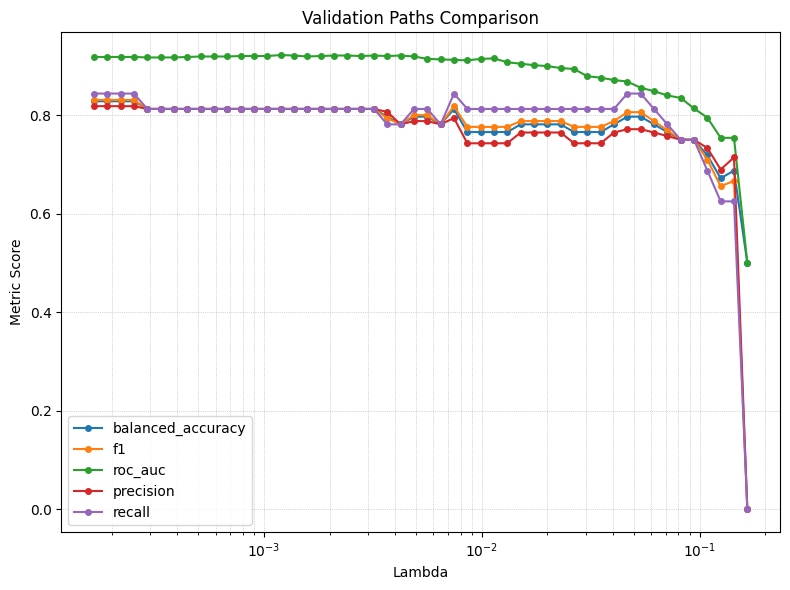

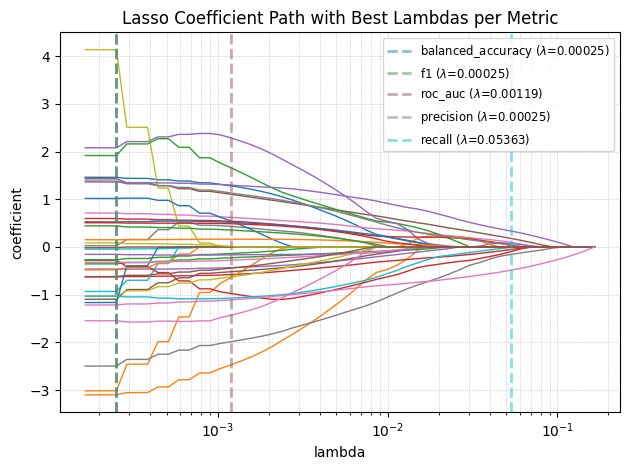


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.02 (Sklearn C = 0.2618)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 0   |        0.037631 |        0.031409 |        0.006222
Feature 2   |       -0.026134 |       -0.019589 |        0.006545
Feature 3   |       -0.202956 |       -0.218174 |        0.015217
Feature 4   |       -0.057722 |       -0.056498 |        0.001224
Feature 5   |        0.443939 |        0.426140 |        0.017799
Feature 6   |        0.264799 |        0.258083 |        0.006716
Feature 12  |        0.300735 |        0.267678 |        0.033057
Feature 13  |       -0.360755 |       -0.351653 |        0.009102
Feature 14  |        0.073737 |        0.046380 |        0.027357
Feature 17  |       -0.658126 |       -0.644380 |        0.013745
... (Skipping remaining 27 features)
-------------------------

In [4]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/gallstones.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.02)

#### musk

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.000149
  -> Best Validation balanced_accuracy: 0.8665

Evaluating metric: F1
  -> Best Lambda: 0.000149
  -> Best Validation f1: 0.7969

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.000097
  -> Best Validation roc_auc: 0.9689

Evaluating metric: PRECISION
  -> Best Lambda: 0.048155
  -> Best Validation precision: 1.0000

Evaluating metric: RECALL
  -> Best Lambda: 0.000149
  -> Best Validation recall: 0.7598


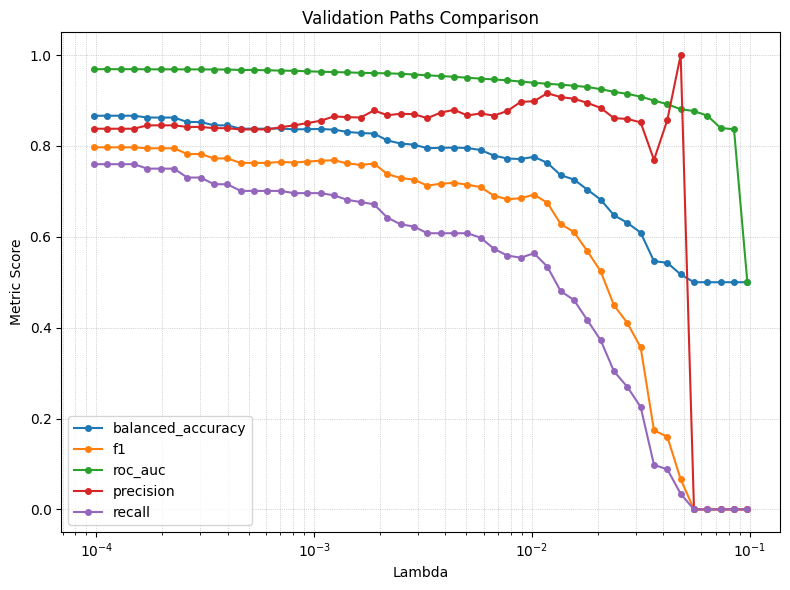

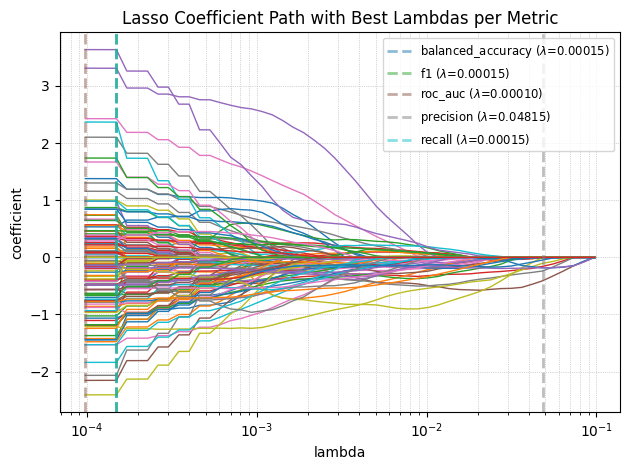


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.00015 (Sklearn C = 1.6844)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 0   |       -1.279032 |       -1.832174 |        0.553141
Feature 1   |       -0.099854 |       -0.142530 |        0.042677
Feature 2   |       -0.782067 |       -0.698390 |        0.083677
Feature 3   |       -0.832121 |       -1.038990 |        0.206868
Feature 4   |        0.125797 |        0.096197 |        0.029600
Feature 5   |       -0.732517 |       -0.745546 |        0.013029
Feature 6   |        0.013710 |        0.000000 |        0.013710
Feature 7   |        1.172401 |        1.144399 |        0.028002
Feature 8   |       -0.237410 |       -0.198429 |        0.038981
Feature 9   |       -1.069928 |       -0.904109 |        0.165819
... (Skipping remaining 124 features)
---------------------

In [ ]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/musk.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.00015)

#### spectrometer

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.010188
  -> Best Validation balanced_accuracy: 0.9545

Evaluating metric: F1
  -> Best Lambda: 0.010188
  -> Best Validation f1: 0.9524

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.048036
  -> Best Validation roc_auc: 1.0000

Evaluating metric: PRECISION
  -> Best Lambda: 0.031470
  -> Best Validation precision: 1.0000

Evaluating metric: RECALL
  -> Best Lambda: 0.010188
  -> Best Validation recall: 0.9091


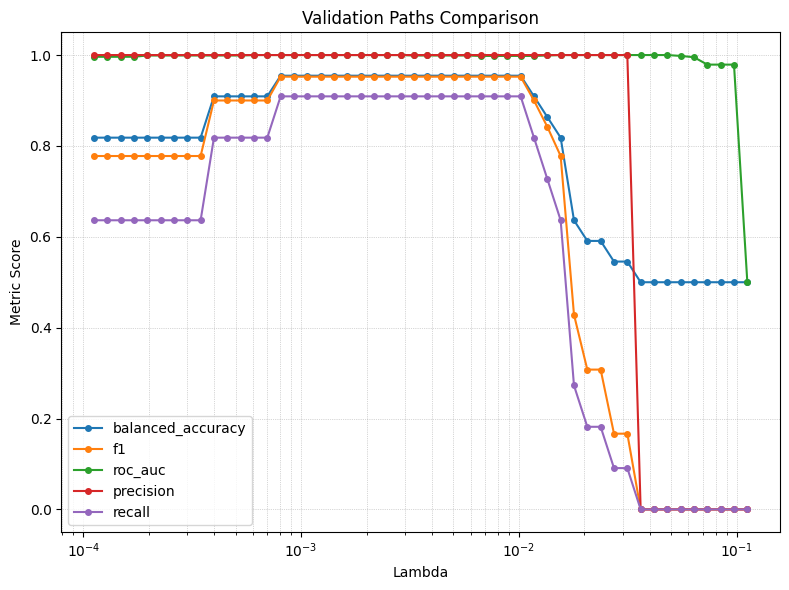

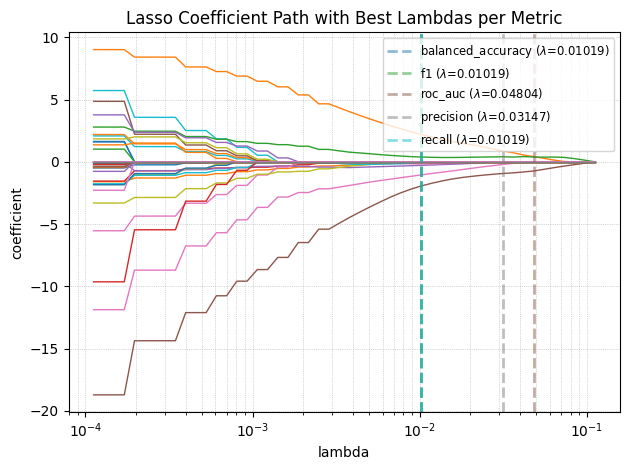


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.01 (Sklearn C = 0.3145)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 1   |       -0.077312 |       -0.070718 |        0.006594
Feature 4   |       -0.275306 |       -0.305233 |        0.029927
Feature 5   |       -1.682837 |       -0.803614 |        0.879223
Feature 6   |       -1.239909 |       -1.124437 |        0.115472
Feature 10  |        0.006292 |        0.000000 |        0.006292
Feature 11  |        2.165978 |        1.638796 |        0.527182
Feature 26  |       -0.283189 |       -0.293113 |        0.009923
Feature 28  |       -0.015229 |        0.000000 |        0.015229
Feature 29  |       -0.068969 |       -0.025651 |        0.043317
Feature 32  |        0.386903 |        0.058088 |        0.328815
... (Skipping remaining 38 features)
-------------------------

In [ ]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/spectrometer.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.01)

#### bioresponse

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.002648
  -> Best Validation balanced_accuracy: 0.7765

Evaluating metric: F1
  -> Best Lambda: 0.002300
  -> Best Validation f1: 0.8061

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.006169
  -> Best Validation roc_auc: 0.8527

Evaluating metric: PRECISION
  -> Best Lambda: 0.002648
  -> Best Validation precision: 0.7793

Evaluating metric: RECALL
  -> Best Lambda: 0.241025
  -> Best Validation recall: 1.0000


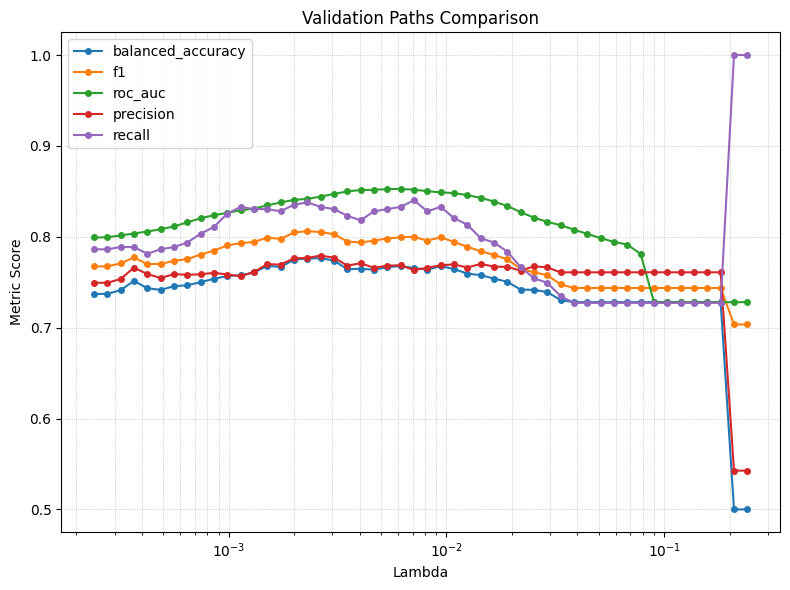

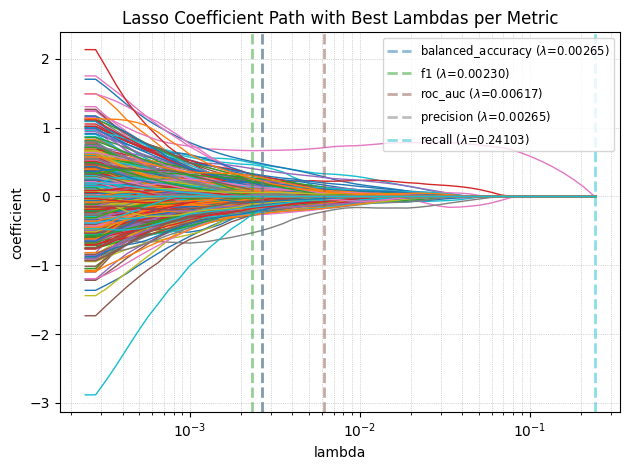


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.01 (Sklearn C = 0.0444)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 9   |        0.290340 |        0.282662 |        0.007677
Feature 13  |        0.037403 |        0.040570 |        0.003168
Feature 17  |        0.035574 |        0.035894 |        0.000320
Feature 26  |        0.739105 |        0.740983 |        0.001878
Feature 40  |       -0.102140 |       -0.116161 |        0.014021
Feature 50  |        0.005910 |        0.004755 |        0.001156
Feature 59  |       -0.010587 |       -0.015144 |        0.004557
Feature 65  |        0.013248 |        0.013578 |        0.000330
Feature 77  |        0.104857 |        0.087423 |        0.017434
Feature 80  |        0.173279 |        0.174772 |        0.001493
... (Skipping remaining 1740 features)
-----------------------

In [ ]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/bioresponse.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.01)

#### TODO: figure out jak sensownie porównać z sklearn, losowa lambda raczej słabo, najlepsza z fisty też słabo, najlepsza z obu??? ale nie wiem czy standardowy sklearn sobie automatycznie dobiera najlepsza czy nie